# Deeplearning Final Project


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/DEEPLRL_Data'

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import SeparableConv2D
import matplotlib.pyplot as plt
import numpy as np

import os
from PIL import Image

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(f"Training samples  : {train_data.samples}")
print(f"Validation samples: {validation_data.samples}")
print(f"Class indices     : {train_data.class_indices}")

Found 600 images belonging to 5 classes.
Found 150 images belonging to 5 classes.
Training samples  : 600
Validation samples: 150
Class indices     : {'hdmi': 0, 'rj45': 1, 'sata': 2, 'usba': 3, 'vga': 4}


In [ ]:
dataset_classes = ['hdmi', 'rj45', 'sata', 'usba', 'vga']
problem_files = []

for cls in dataset_classes:
    folder = os.path.join(dataset_path, cls)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            fpath = os.path.join(folder, fname)
            try:
                img = Image.open(fpath)
                if img.mode != 'RGB':
                    print(f"⚠️ Non-RGB image: {fpath} — mode: {img.mode}")
                    problem_files.append(fpath)
                    # Auto-convert and save
                    img.convert('RGB').save(fpath)
            except Exception as e:
                print(f"❌ Corrupt image: {fpath} — {e}")
                problem_files.append(fpath)

if not problem_files:
    print("✅ All images are RGB — no issues found")
else:
    print(f"\nFixed {len(problem_files)} problem files")

✅ All images are RGB — no issues found


In [ ]:
model = models.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),

    # Same as original
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Same as original
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # UPGRADE 1: extra block for more feature learning
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # UPGRADE 2: GlobalAveragePooling instead of Flatten
    layers.GlobalAveragePooling2D(),

    # UPGRADE 3: bigger dense + dropout before output
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(train_data.num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,557 (498.27 KB)

 Trainable params: 127,557 (498.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,          # stop after 3 epochs of no improvement
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
for cls in ['hdmi', 'rj45', 'sata', 'usba', 'vga']:
    folder = os.path.join(dataset_path, cls)
    contents = os.listdir(folder)
    subfolders = [f for f in contents if os.path.isdir(os.path.join(folder, f))]
    images = [f for f in contents if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f"{cls}: {len(images)} images, {len(subfolders)} subfolders {subfolders if subfolders else ''}")

hdmi: 149 images, 0 subfolders 
rj45: 150 images, 0 subfolders 
sata: 150 images, 0 subfolders 
usba: 150 images, 0 subfolders 
vga: 150 images, 0 subfolders 


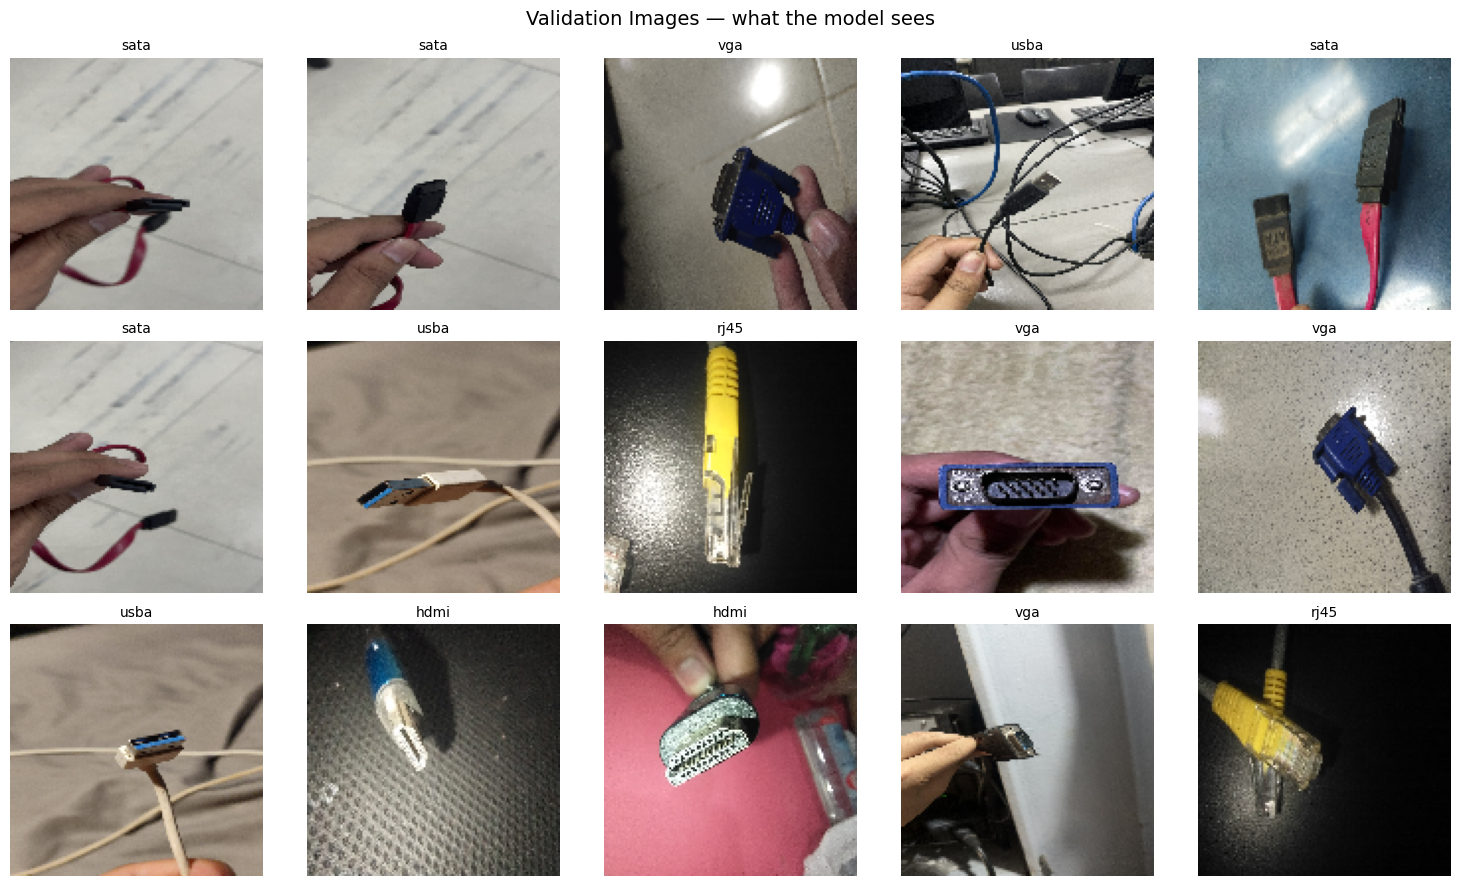

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

val_batch_x, val_batch_y = next(iter(validation_data))

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
class_labels = list(train_data.class_indices.keys())

for i, ax in enumerate(axes.flat):
    if i < len(val_batch_x):
        ax.imshow(val_batch_x[i])
        label_idx = np.argmax(val_batch_y[i])
        ax.set_title(class_labels[label_idx], fontsize=10)
        ax.axis('off')

plt.suptitle('Validation Images — what the model sees', fontsize=14)
plt.tight_layout()
plt.show()

In [1]:
history = model.fit(
    train_data,
    epochs=30,
    validation_data=validation_data,
    callbacks=callbacks
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 112s 6s/step - accuracy: 0.2750 - loss: 1.5907 - val_accuracy: 0.1867 - val_loss: 1.5999 - learning_rate: 0.0010
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.3650 - loss: 1.4478 - val_accuracy: 0.3133 - val_loss: 1.6264 - learning_rate: 0.0010
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.4500 - loss: 1.2841 - val_accuracy: 0.3267 - val_loss: 1.7453 - learning_rate: 0.0010
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.4867 - loss: 1.1866 - val_accuracy: 0.3400 - val_loss: 1.6192 - learning_rate: 0.0010
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.5217 - loss: 1.1222 - val_accuracy: 0.3933 - val_loss: 1.6921 - learning_rate: 0.0010
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.5367 - loss: 1.1115 - val_accuracy: 0.4600 - val_loss: 1.8150 - learning_rate: 0.0010
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.6217 - loss: 0.9714 - val_accuracy:

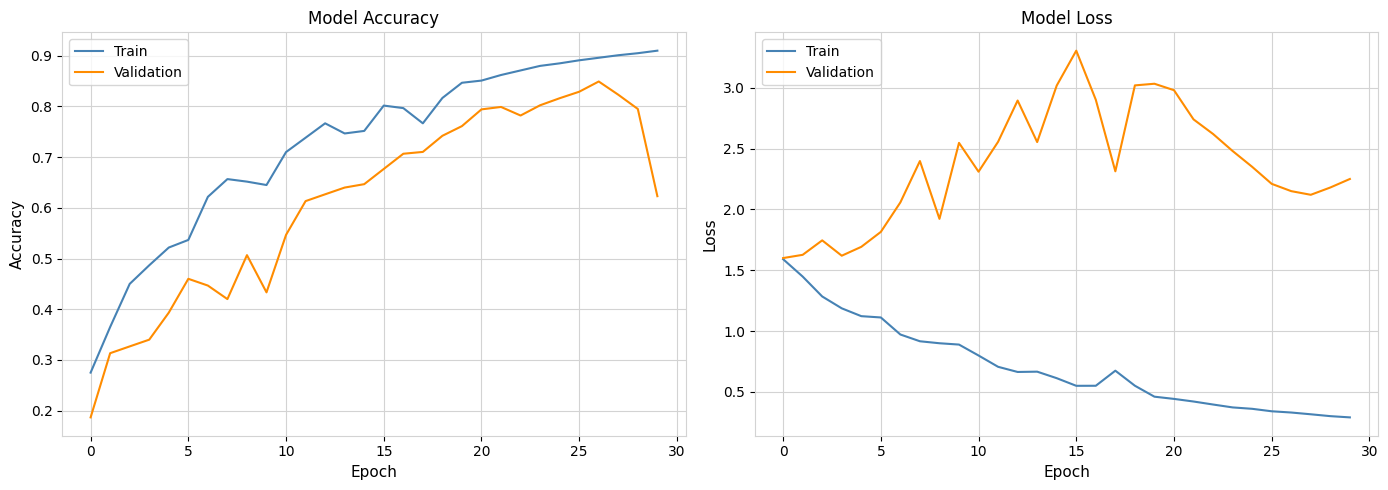

Validation Accuracy: 0.8492
Validation Loss    : 2.1500


In [2]:
loss, accuracy = model.evaluate(validation_data)
print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation Loss    : {loss:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()